<a href="https://colab.research.google.com/github/one-2730/ESSA-25-1/blob/Assignment/ESSA_OB_250307_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##4.5 규제가 있는 선형 모델

###4.5.1 릿지 회귀

In [1]:
import numpy as np

m = 100
X = 6 * np.random.rand(m, 1)-3
y = 0.5 * X**2 + X + 2 + np.random.rand(m, 1)

In [2]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha = 1, solver = "cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([5.41733551])

In [3]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty = "l2")
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([5.39658542])

###4.5.2 라쏘 회귀

In [4]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha = 0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.37089806])

###4.5.3 엘라스틱넷

In [5]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha = 0.1, l1_ratio = 0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([5.37129791])

###4.5.4 조기 종료

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import mean_squared_error

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2)

poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree = 90, include_bias = False)),
    ("std_scaler", StandardScaler())
])
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor(max_iter = 1, tol = None, warm_start = True, penalty = None, learning_rate = 'constant', eta0 = 0.0005)

minimum_val_error = float('inf')
best_epoch = None
best_model = None

for epoch in range(1000):
  sgd_reg.fit(X_train_poly_scaled, y_train)
  y_val_predict = sgd_reg.predict(X_val_poly_scaled)
  val_error = mean_squared_error(y_val, y_val_predict)
  if val_error < minimum_val_error:
    minimum_val_error = val_error
    best_epoch = epoch
    best_model = clone(sgd_reg)

##4.6 로지스틱 회귀

###4.6.1 확률 추정

로지스틱 회귀는 y 대신 logit(y)를 출력
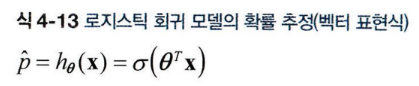

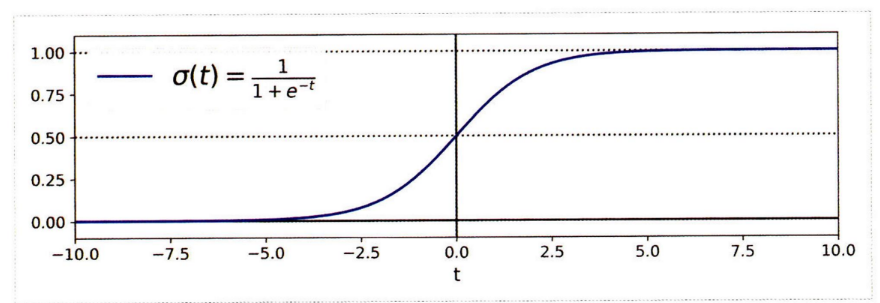
*로지스틱 함수: 0과 1사이 값을  출력하는 시그모이드 함수, 로짓함수와 역함수 관계

예측된 확률이 0.5(꼭 0.5가 아닐 수 있음, breakthrough는 설정 가능)이상이면 1로, 아니라면 0으로 예측

###4.6.2 훈련과 비용 함수

로지스틱 회귀 모델의 훈련 목적: y=1에 대해서는 높은 확률을 추정하고 y=0에 대해 낮은 확률을 추정하는 모델의 파라미터 벡터 theta를 찾는 것.
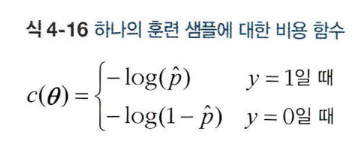

t가 0에 가까워지면 -log(t)가 매우 커짐
따라서 잘못 추정하면 비용이 커지고, 알맞게 예측하면 비용이 0에 가까워짐. 전체 훈련 세트에 대한 비용함수는 모든 훈련 샘플의 비용을 평균한 것으로 로그손실이라 부름
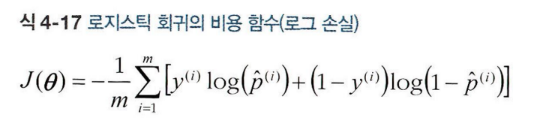

이 비용함수의 최솟값을 계산하는 정규방정식 등의 해가 없음. 그러나 볼록함수이므로 경사하강법이 전역 최솟값을 찾는 것을 보장함 비용함수의 j번째 파라미터 theta(j)에 대해 편미분 하면 다음과 같음. 모든 편도함수를 포함한 그레이디언트 벡터를 만들면 경사하강법 알고리즘을 사용 가능
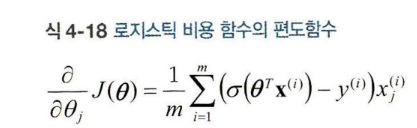

###4.6.3 결정경계

In [9]:
from sklearn import datasets
iris = datasets.load_iris()
print(list(iris.keys()))
X = iris['data'][:, 3:]
y = (iris['target'] == 2).astype(int)

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


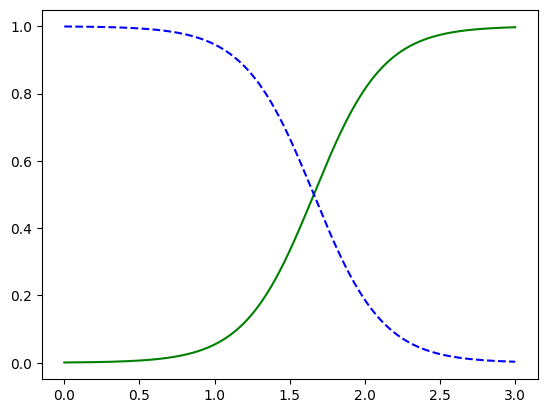

In [11]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

log_reg = LogisticRegression()
log_reg.fit(X, y)

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

plt.plot(X_new, y_proba[:, 1], "g-", label = "Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", label = 'Not Iris virginica')
plt.show()

In [12]:
log_reg.predict([[1.7], [1.5]])

array([1, 0])

###4.6.4 소프트맥스 회귀

In [14]:
X = iris['data'][:, (2, 3)]
y = iris['target']

softmax_reg = LogisticRegression(multi_class = "multinomial", solver = 'lbfgs', C = 10)
softmax_reg.fit(X, y)

print(softmax_reg.predict([[5, 2]]))
print(softmax_reg.predict_proba([[5, 2]]))

[2]
[[6.21626375e-07 5.73689803e-02 9.42630398e-01]]


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
